In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.calibration import calibration_curve
from sklearn.model_selection import cross_validate, GridSearchCV, RandomizedSearchCV
from tqdm.auto import tqdm
from tqdm_joblib import tqdm_joblib

In [2]:
df = pd.read_csv('Datasets\cumulative_cleaned.csv')
df.sample(5)

,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_steff,koi_slogg,koi_srad,koi_kepmag,koi_disposition
3721,65.583666,182.649338,0.720,5.01216,242400.0,41.22,371.0,4.50,1649.5,5516.0,4.650,0.666,15.743,0
5990,1.227751,132.563460,0.262,1.60200,327.6,1.00,1094.0,340.64,20.3,4551.0,4.713,0.560,15.715,0
3638,70.582847,190.499785,0.882,8.81169,150930.0,50.88,435.0,8.45,2424.0,5973.0,4.516,0.904,14.624,0
1758,11.322697,136.055110,0.951,3.51700,311.0,1.51,554.0,22.24,16.0,4563.0,4.624,0.642,15.006,1
349,2.002780,261.957910,0.242,2.23100,260.5,1.42,1311.0,696.40,22.2,5346.0,4.440,0.892,14.606,0


In [3]:
features = ['koi_period', 'koi_time0bk',  'koi_impact', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_teq', 'koi_insol', 'koi_model_snr', 'koi_steff', 'koi_slogg',  'koi_srad','koi_kepmag']

In [4]:
X = df[features]
y = df['koi_disposition']

**Train-Test Splitting**

In [5]:
X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [6]:
skewed_cols = ['koi_period', 'koi_time0bk',  'koi_impact', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_teq', 'koi_insol', 'koi_model_snr', 'koi_steff', 'koi_slogg',  'koi_srad','koi_kepmag']

**Log Transformation**

In [7]:
# log transformation
X_train[skewed_cols] = np.log1p(X_train[skewed_cols])
X_test[skewed_cols] = np.log1p(X_test[skewed_cols])

**Scaling**

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)   

**Logistic Regression**

In [9]:
log_reg_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000, class_weight='balanced'))
])

log_reg_pipeline.fit(X_train, y_train)

y_pred_logreg = log_reg_pipeline.predict(X_test)
y_proba_logreg = log_reg_pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_logreg))

              precision    recall  f1-score   support

           0       0.93      0.81      0.87      1417
           1       0.69      0.88      0.77       688

    accuracy                           0.83      2105
   macro avg       0.81      0.84      0.82      2105
weighted avg       0.85      0.83      0.84      2105



**Random Forest**

In [10]:
rf_pipeline = Pipeline(steps=[
    ('model', RandomForestClassifier(n_estimators= 10, random_state=42, class_weight='balanced'))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.93      0.93      1417
           1       0.85      0.87      0.86       688

    accuracy                           0.91      2105
   macro avg       0.90      0.90      0.90      2105
weighted avg       0.91      0.91      0.91      2105



**Gradient Boost**

In [11]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline(steps=[
    ('model', GradientBoostingClassifier(random_state=42))
])

gb_pipeline.fit(X_train, y_train)

y_pred_gb = gb_pipeline.predict(X_test)
y_proba_gb = gb_pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1417
           1       0.87      0.89      0.88       688

    accuracy                           0.92      2105
   macro avg       0.91      0.91      0.91      2105
weighted avg       0.92      0.92      0.92      2105



**Support Vector Machine**

In [12]:
svm_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', class_weight='balanced', random_state=42 ))
])

svm_pipeline.fit(X_train, y_train)

y_pred_svm = svm_pipeline.predict(X_test)
y_proba_svm = svm_pipeline.decision_function(X_test)

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.97      0.89      0.93      1417
           1       0.80      0.95      0.87       688

    accuracy                           0.91      2105
   macro avg       0.89      0.92      0.90      2105
weighted avg       0.92      0.91      0.91      2105



**Model Performance Comparison**

For this project, macro F1-score and ROC-AUC are especially important. Macro F1-score calculates the F1-score for both classes and averages them equally, so it is better for an imbalanced dataset. ROC-AUC helps evaluate the model's ability to separate confirmed planets from false positives across thresholds.

In [13]:
results = []

models = {
    'Logistic Regression': (y_pred_logreg, y_proba_logreg),
    'Random Forest': (y_pred_rf, y_proba_rf),
    'Gradient Boosting': (y_pred_gb, y_proba_gb),
    'SVM': (y_pred_svm, y_proba_svm)
}

for name, (pred, proba) in models.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision Macro': precision_score(y_test, pred, average='macro', zero_division=0),
        'Recall Macro': recall_score(y_test, pred, average='macro', zero_division=0),
        'F1 Macro': f1_score(y_test, pred, average='macro'),
        'ROC_AUC': roc_auc_score(y_test, proba)
    })

results_df = pd.DataFrame(results).sort_values(by='F1 Macro', ascending=False)
results_df

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,ROC_AUC
2,Gradient Boosting,0.919240,0.906675,0.910851,0.908707,0.966850
3,SVM,0.907363,0.888049,0.918481,0.899112,0.968498
1,Random Forest,0.910214,0.896427,0.900782,0.898541,0.958094
0,Logistic Regression,0.831829,0.811552,0.844056,0.819935,0.916127


**Cross Validation**

A resampling technique that repeatedly partioning the dataset into training and testing subsets, ensuring that every data point is utilized for both training and evaluation. 

In [14]:
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc']

pipelines = {
    'Logistic Regression': log_reg_pipeline,
    'Random Forest': rf_pipeline,
    'Gradient Boosting': gb_pipeline,
    'SVM': svm_pipeline
}

cv_results = []

for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring)

    cv_results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision Macro': scores['test_precision_macro'].mean(),
        'Recall Macro': scores['test_recall_macro'].mean(),
        'F1 Macro': scores['test_f1_macro'].mean(),
        'ROC_AUC': scores['test_roc_auc'].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by='F1 Macro', ascending=False)

cv_results_df

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,ROC_AUC
2,Gradient Boosting,0.899359,0.901200,0.890404,0.887031,0.969086
1,Random Forest,0.895225,0.895663,0.882841,0.880826,0.956882
3,SVM,0.816108,0.813298,0.841164,0.807254,0.916756
0,Logistic Regression,0.796721,0.793392,0.823744,0.787755,0.889092


**Hypterparameter Tuning**

In [15]:
gb_tuning_pipeline = Pipeline(steps=[
    ('model', GradientBoostingClassifier(
        random_state=42,))
])

param_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'model__max_depth': [2, 3, 4, 5],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    estimator=gb_tuning_pipeline,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1_macro',      # since you're comparing by F1 Macro
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

total_fits = random_search.n_iter * random_search.cv

with tqdm_joblib(tqdm(desc="RandomizedSearchCV", total=total_fits)):
    random_search.fit(X_train, y_train)

print(random_search.best_params_)
print(random_search.best_score_)

RandomizedSearchCV:   0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

Fitting 5 folds for each of 50 candidates, totalling 250 fits
{'model__subsample': 1.0, 'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 5, 'model__learning_rate': 0.1}
0.9240741868640695


In [16]:
#Evaluate tuned Gradient Boosting on the test set

best_gb_pipeline = random_search.best_estimator_

y_pred_best_gb = best_gb_pipeline.predict(X_test)
y_proba_best_gb = best_gb_pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_best_gb))
print('ROc-AUC:', roc_auc_score(y_test, y_proba_best_gb))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94      1417
           1       0.88      0.90      0.89       688

    accuracy                           0.93      2105
   macro avg       0.91      0.92      0.92      2105
weighted avg       0.93      0.93      0.93      2105

ROc-AUC: 0.9728709523887676


In [17]:
#Add tuned Gradient Boosting to model comparison

tuned_gb_result = pd.DataFrame([{
    'Model': 'Tuned Gradient Boosting',
    'Accuracy': accuracy_score(y_test, y_pred_best_gb),
    'Precision Macro': precision_score(y_test, y_pred_best_gb, average='macro', zero_division=0),
    'Recall Macro': recall_score(y_test, y_pred_best_gb, average='macro', zero_division=0),
    'F1 Macro': f1_score(y_test, y_pred_best_gb, average='macro'),
    'ROC_AUC': roc_auc_score(y_test, y_proba_best_gb)
}])

final_results_df = pd.concat([results_df, tuned_gb_result], ignore_index=True)
final_results_df = final_results_df.sort_values(by='F1 Macro', ascending=False)

final_results_df

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,ROC_AUC
4,Tuned Gradient Boosting,0.926366,0.914152,0.919883,0.916913,0.972871
0,Gradient Boosting,0.919240,0.906675,0.910851,0.908707,0.966850
1,SVM,0.907363,0.888049,0.918481,0.899112,0.968498
2,Random Forest,0.910214,0.896427,0.900782,0.898541,0.958094
3,Logistic Regression,0.831829,0.811552,0.844056,0.819935,0.916127


**Final Model Selection**

In [18]:
#Select final model automatically from the comparison table

model_objects = {
    'Logistic Regression': (log_reg_pipeline, y_pred_logreg, y_proba_logreg),
    'Random Forest': (rf_pipeline, y_pred_rf, y_proba_rf),
    'Gradient Boosting': (gb_pipeline, y_pred_gb, y_proba_gb),
    'SVM': (svm_pipeline, y_pred_svm, y_proba_svm),
    'Tuned Gradient Boosting': (best_gb_pipeline, y_pred_best_gb, y_proba_best_gb)
}

best_model_name = final_results_df.sort_values(
    by=['F1 Macro', 'ROC_AUC'],
    ascending=False
).iloc[0]['Model']

best_pipeline, y_pred_best, y_proba_best = model_objects[best_model_name]

print("Final selected model:", best_model_name)
print(final_results_df[final_results_df['Model'] == best_model_name])

Final selected model: Tuned Gradient Boosting
                     Model  Accuracy  Precision Macro  Recall Macro  F1 Macro  \
4  Tuned Gradient Boosting  0.926366         0.914152      0.919883  0.916913   

    ROC_AUC  
4  0.972871  


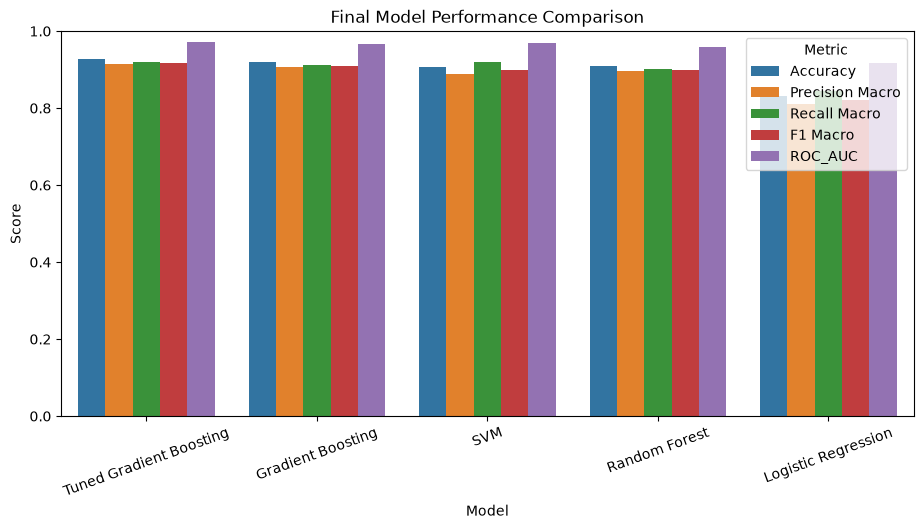

In [19]:
# Plot final model comparison

final_results_melted = final_results_df.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'Precision Macro', 'Recall Macro', 'F1 Macro', 'ROC_AUC'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(11, 5))
sns.barplot(
    data=final_results_melted,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title('Final Model Performance Comparison')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

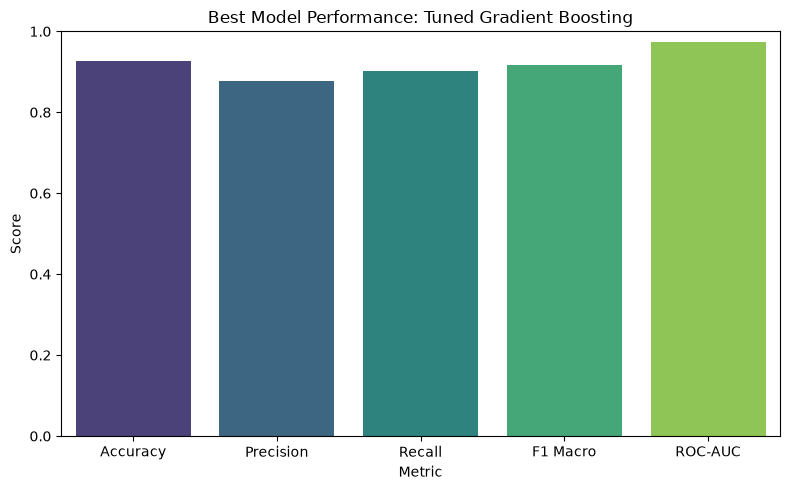

,Metric,Score
0,Accuracy,0.926366
1,Precision,0.876945
2,Recall,0.901163
3,F1 Macro,0.916913
4,ROC-AUC,0.972871


In [20]:
# The final model is selected based on the F1 and ROC_AUC scores due to class imbalance, the goal is here to identify confirmed planets from the false positives.

best_model_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Macro', 'ROC-AUC'],
    'Score': [
        accuracy_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_best),
        recall_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_best, average='macro'),
        roc_auc_score(y_test, y_proba_best)
    ]
})

plt.figure(figsize=(8, 5))

sns.barplot(data=best_model_metrics, x='Metric', y='Score', palette='viridis', hue='Metric')

plt.title(f'Best Model Performance: {best_model_name}')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.xlabel('Metric')
plt.tight_layout()
plt.show()

best_model_metrics

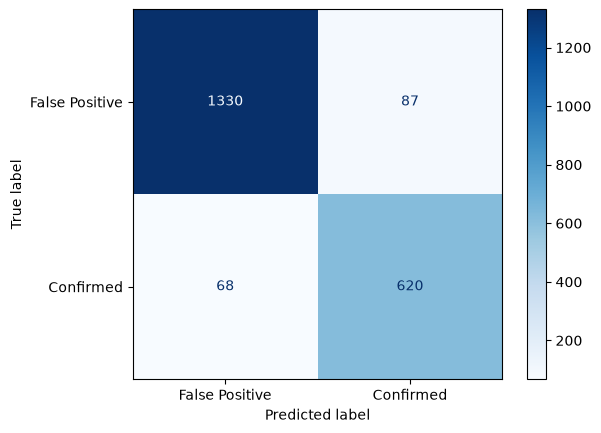

In [21]:
# In this domain, missing a real planet (a false negative) is arguably worse than a false alarm — you'd rather flag a few extra candidates for telescope follow-up than throw away a real discovery. Keep that asymmetry in mind; it'll matter later if you ever tune the decision threshold.


cm = confusion_matrix(y_test, y_pred_best, labels=best_gb_pipeline.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['False Positive', 'Confirmed'])
disp.plot(cmap='Blues', values_format='d')

- 620 (TP) - real exoplanets correctly confirmed
- 1330 (TN) - real false positives correctly confirmed
- 87 (FP) - false positives the model wrongly called confirmed
- 68 (FN) - real exoplanets the model missed, calling them false negatives

The class imbalance also shows here: 1417 (1330 + 87) true False Positive cases vs 688 (620 + 68) confirmed cases - roughly 2:1.

**Error Analysis**

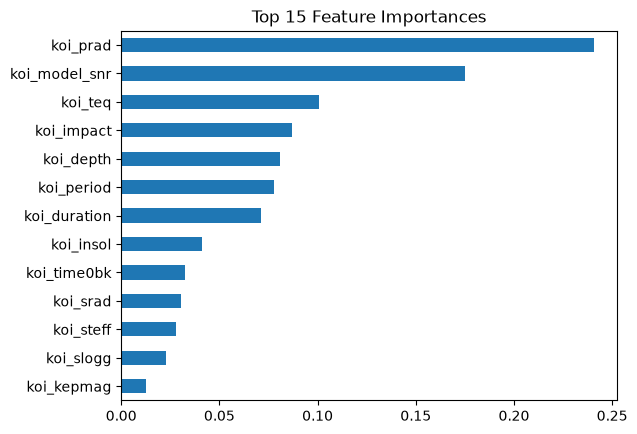

In [22]:
final_model = best_pipeline.named_steps['model']

importances = pd.Series(final_model.feature_importances_, index=features)
importances.sort_values(ascending=False).head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances')
plt.show()

ROC Curve:

The ROC curve rises steeply toward the top-left corner, indicating that the model achieves a high true positive rate while maintaining a very low false positive rate across most classification thresholds. The high AUC of 0.97 demonstrates excellent discriminative ability between the positive and negative classes.

Precision-Recall Curve:

The Precision-Recall curve remains close to 0.95 precision across most of the recall range, indicating that the model's positive predictions are highly accurate while successfully identifying most positive instances. Precision drops sharply only when recall approaches 1.0, reflecting the expected increase in false positives at very low classification thresholds.

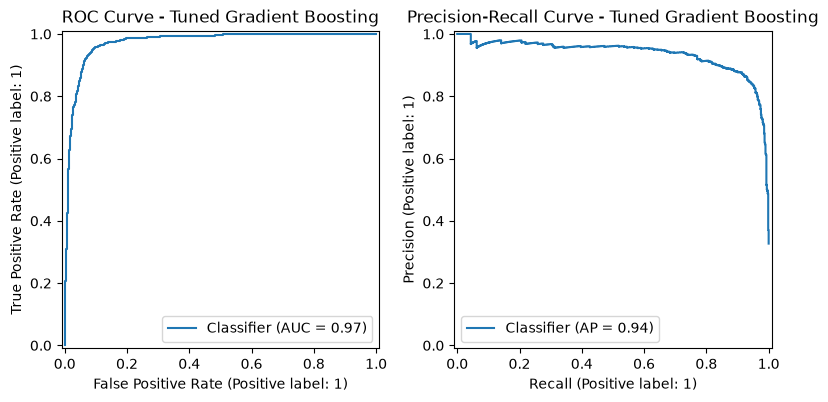

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_proba_best, ax=ax[0])
ax[0].set_title(f'ROC Curve - {best_model_name}')


PrecisionRecallDisplay.from_predictions(y_test, y_proba_best, ax=ax[1])
ax[1].set_title(f'Precision-Recall Curve - {best_model_name}')
plt.tight_layout()
plt.show()

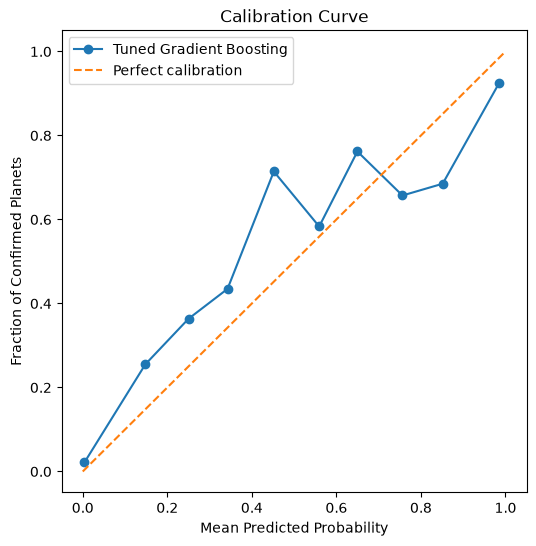

In [37]:
prob_true, prob_pred = calibration_curve(y_test, y_proba_best, n_bins=10, strategy='uniform')

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label=best_model_name)
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')

plt.title('Calibration Curve')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Confirmed Planets')
plt.legend()
plt.show()